# Graph Convolutional Neural Networks

## Import Required Libraries

In [154]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


## GCN Model Definition

In [155]:
class GCN_Rating_Classification(torch.nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, dropout_rate):
        super(GCN_Rating_Classification, self).__init__()
        
        # Initialize a list to hold GCN layers
        self.convs = torch.nn.ModuleList()

        # Initialize droput layer
        self.dropout_rate = dropout_rate

        # First layer: input_dim → first hidden dim
        self.convs.append(GCNConv(input_dim, hidden_dims[0]))

        # Hidden layers: hidden_dims[i-1] → hidden_dims[i]
        for i in range(1, len(hidden_dims)):
            self.convs.append(GCNConv(hidden_dims[i - 1], hidden_dims[i]))

        # Final layer: last hidden dim → output
        self.out = GCNConv(hidden_dims[-1], output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p = self.dropout_rate, training = self.training)

        x = self.out(x, edge_index)
        return F.log_softmax(x, dim = 1)


## Model Training Function

In [156]:
def train_model(data, input_dim, output_dim, hidden_dim, lr, weight_decay, optimizer_type, dropout_rate, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = GCN_Rating_Classification(input_dim, hidden_dim, output_dim, dropout_rate).to(device)
    data = data.to(device)

    if optimizer_type == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = weight_decay)
    elif optimizer_type == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr = lr, weight_decay = weight_decay)
    elif optimizer_type == "RMSprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr = lr, weight_decay = weight_decay)
    else:
        raise ValueError("Unsupported optimizer")

    train_losses = []
    val_losses = []
    val_accuracies = []

    best_val_loss = float("inf")
    best_model_state = None
    epochs_no_improve = 0
    patience = 20

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_out = out[data.val_mask]
            val_y = data.y[data.val_mask]
            val_loss = F.nll_loss(val_out, val_y)
            val_losses.append(val_loss.item())

            val_pred = out.argmax(dim = 1)[data.val_mask]
            val_acc = (val_pred == val_y).sum().item() / int(data.val_mask.sum())
            val_accuracies.append(val_acc)

            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                epochs_no_improve = 0
                best_model_state = model.state_dict()
            else:
                epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

    model.load_state_dict(best_model_state)

    best_val_loss = val_losses[-1]
    
    return model, best_val_loss, train_losses, val_accuracies, val_losses

## Hyperparameter Tuning Function

In [157]:
def hyperparameter_tuning(data, input_dim, output_dim, param_grid, epochs):
    best_model = None
    best_loss = float("inf")
    best_config = None

    model_counter = 1
    total_model_count = (len(param_grid['hidden_dim']) *
                    len(param_grid['lr']) *
                    len(param_grid['weight_decay']) *
                    len(param_grid['optimizer']) *
                    len(param_grid['dropout_rate']))

    for hidden_dim in param_grid['hidden_dim']:
        for lr in param_grid['lr']:
            for weight_decay in param_grid['weight_decay']:
                for opt_name in param_grid['optimizer']:
                    for dropout_rate in param_grid['dropout_rate']:
                        print(f"Model {model_counter}/{total_model_count}: hidden_dim = {hidden_dim} | lr = {lr} | weight_decay = {weight_decay} | optimizer = {opt_name} | dropout_rate = {dropout_rate}")
                        try:
                            model, val_loss, train_losses, val_accuracies, val_losses  = train_model(data, input_dim, output_dim, hidden_dim, lr, weight_decay, opt_name, dropout_rate, epochs)
                            print(f"Best Validation Loss: {val_loss:.4f}\n")
                            
                            if val_loss < best_loss:
                                best_loss = val_loss
                                best_model = model
                                best_config = {
                                    "hidden_dim": hidden_dim,
                                    "lr": lr,
                                    "weight_decay": weight_decay,
                                    "optimizer": opt_name,
                                    "dropout_rate": dropout_rate
                                }
                        except Exception as e:
                            print(f"Failed with {opt_name}: {e}")

                        model_counter += 1

    return best_model, best_config, best_loss


## Movie Rating Classification

### Load Dataset and Preprocess

In [158]:
# Load GraphML with NetworkX
G = nx.read_graphml("../data/networks/movie_similarity_network.graphml")

# Extract node features and labels
node_ids = list(G.nodes)
num_nodes = len(node_ids)

# Pick node attributes as features
feature_names = ["budget", "revenue", "roi", "oscar_noms", "oscar_wins"]
features = []
ratings = []

for n in node_ids:
    node_data = G.nodes[n]
    # Extract features and convert to float, handle missing data if needed
    f = []
    for attr in feature_names:
        val = node_data.get(attr)
        if val is None:
            val = 0.0  # or np.nan and handle later
        else:
            val = float(val)
        f.append(val)
    features.append(f)

    # Extract rating for label
    rating_val = node_data.get("rating")
    rating_val = float(rating_val) if rating_val is not None else 0.0
    ratings.append(rating_val)

numeric_features = np.array(features)
ratings = np.array(ratings)

### Encode Text Features

In [159]:
# Extract genre strings
genre_lists = []
for n in node_ids:
    raw = G.nodes[n].get("genre", "[]")
    try:
        genres = eval(raw)  # convert string to list
    except:
        genres = []
    genre_lists.append(genres)

# Convert to multi-hot encoding
mlb = MultiLabelBinarizer()
genre_features = mlb.fit_transform(genre_lists)

combined_features = np.hstack([numeric_features, genre_features])

### Bucketize Target Variables

In [160]:
# Bucketize ratings into classes
def bucketize_rating_quantile(r, ratings, classes):
    quantiles = [np.quantile(ratings, i / classes) for i in range(1, classes)]
    
    for i, q in enumerate(quantiles):
        if r <= q:
            return i
    return classes - 1

classes = 3
labels = np.array([bucketize_rating_quantile(r, ratings, classes) for r in ratings])

quantiles = [np.quantile(ratings, i / classes) for i in range(1, classes)]
unique, counts = np.unique(labels, return_counts = True)

# Print readable label ranges
for label, count in zip(unique, counts):
    if label == 0:
        print(f"Label {label}: {count} movies - (rating <= {quantiles[0]:.2f})")
    elif label == classes - 1:
        print(f"Label {label}: {count} movies - (rating > {quantiles[-1]:.2f})")
    else:
        lower = quantiles[label - 1]
        upper = quantiles[label]
        print(f"Label {label}: {count} movies - ({lower:.2f} < rating <= {upper:.2f})")

Label 0: 2315 movies - (rating <= 5.73)
Label 1: 2315 movies - (5.73 < rating <= 7.08)
Label 2: 2310 movies - (rating > 7.08)


## Remove NaN Nodes and Edges

In [161]:
features = np.array(combined_features)  # shape (num_nodes, num_features)
labels = np.array(labels)      # your bucketized labels
node_ids = np.array(node_ids)  # original node_ids list (do NOT filter yet)

# Find valid nodes (no NaNs in features)
valid_rows = ~np.isnan(features).any(axis=1)

# Filter features and labels by valid_rows
features_filtered = features[valid_rows]
labels_filtered = labels[valid_rows]

# Build old_to_new mapping for all nodes (original order)
old_to_new = -np.ones(len(node_ids), dtype=int)
old_to_new[np.where(valid_rows)[0]] = np.arange(features_filtered.shape[0])

# Filter edges and remap node indices
edges = list(G.edges())
filtered_edges = []

# Create a mapping from node_id to original index to speed up lookups
node_id_to_idx = {nid: idx for idx, nid in enumerate(node_ids)}

for src, dst in edges:
    if src in node_id_to_idx and dst in node_id_to_idx:
        src_idx = node_id_to_idx[src]
        dst_idx = node_id_to_idx[dst]

        new_src = old_to_new[src_idx]
        new_dst = old_to_new[dst_idx]

        # Only keep edges where both nodes survived filtering
        if new_src != -1 and new_dst != -1:
            filtered_edges.append((new_src, new_dst))

# Build edge_index tensor (transpose to [2, num_edges])
edge_index = torch.tensor(filtered_edges, dtype = torch.long).t().contiguous()

num_nodes_filtered = features_filtered.shape[0]
print("Number of nodes before filtering:", len(node_ids))
print("Number of nodes before filtering:", num_nodes_filtered)

Number of nodes before filtering: 6940
Number of nodes before filtering: 5297


### Standardize Features and Convert to Torch Tensors

In [162]:
scaler = StandardScaler()
features_filtered = scaler.fit_transform(features_filtered)

# Convert to torch tensors
x = torch.tensor(features_filtered, dtype = torch.float)
y = torch.tensor(labels_filtered, dtype = torch.long)

### Split the Dataset into Training, Validation, and Testing Sets

In [163]:
# Create train/test masks
num_nodes = num_nodes_filtered
num_train = int(0.8 * num_nodes)
num_val = int(0.1 * num_nodes)
num_test = num_nodes - num_train - num_val

perm = torch.randperm(num_nodes)
train_idx = perm[:num_train]
val_idx = perm[num_train : num_train + num_val]
test_idx = perm[num_train + num_val:]

train_mask = torch.zeros(num_nodes, dtype = torch.bool)
val_mask = torch.zeros(num_nodes, dtype = torch.bool)
test_mask = torch.zeros(num_nodes, dtype = torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

# Create data object
data = Data(x = x,
            edge_index = edge_index,
            y = y,
            train_mask = train_mask,
            val_mask = val_mask,
            test_mask = test_mask)

In [164]:
nan_mask = np.isnan(features_filtered)
print("NaNs per column:", np.sum(nan_mask, axis = 0))

NaNs per column: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### Tune Hyperparameters

In [165]:
param_grid = {
    "hidden_dim": [[128], [256], [128, 128], [64, 64, 64, 64]],
    "lr": [0.01, 0.001],
    "weight_decay": [5e-4, 1e-3],
    "optimizer": ["Adam", "SGD", "RMSprop"],
    "dropout_rate": [0.2, 0.3]
}

best_model, best_config, best_loss = hyperparameter_tuning(
    data = data,
    input_dim = x.shape[1],
    output_dim = len(np.unique(labels)),
    param_grid = param_grid,
    epochs = 200
)

# Print best model configuration
print(f"Best Config: {best_config}")
print(f"Best Validation Loss: {best_loss:.4f}")


Model 1/96: hidden_dim = [128] | lr = 0.01 | weight_decay = 0.0005 | optimizer = Adam | dropout_rate = 0.2
Early stopping triggered at epoch 67
Best Validation Loss: 1.0631

Model 2/96: hidden_dim = [128] | lr = 0.01 | weight_decay = 0.0005 | optimizer = Adam | dropout_rate = 0.3
Early stopping triggered at epoch 115
Best Validation Loss: 1.0571

Model 3/96: hidden_dim = [128] | lr = 0.01 | weight_decay = 0.0005 | optimizer = SGD | dropout_rate = 0.2
Early stopping triggered at epoch 54
Best Validation Loss: 1.0863

Model 4/96: hidden_dim = [128] | lr = 0.01 | weight_decay = 0.0005 | optimizer = SGD | dropout_rate = 0.3
Early stopping triggered at epoch 101
Best Validation Loss: 1.0936

Model 5/96: hidden_dim = [128] | lr = 0.01 | weight_decay = 0.0005 | optimizer = RMSprop | dropout_rate = 0.2
Early stopping triggered at epoch 36
Best Validation Loss: 1.0738

Model 6/96: hidden_dim = [128] | lr = 0.01 | weight_decay = 0.0005 | optimizer = RMSprop | dropout_rate = 0.3
Early stopping tr

### Train the Best Model

In [166]:
# Retrain with best hyperparameters
best_model, best_val_loss, train_losses, val_accuracies, val_losses = train_model(
    data = data,
    input_dim = data.num_node_features,
    output_dim = len(np.unique(labels)),
    hidden_dim = best_config["hidden_dim"],
    lr = best_config["lr"],
    weight_decay = best_config["weight_decay"],
    optimizer_type = best_config["optimizer"],
    dropout_rate = best_config["dropout_rate"],
    epochs = 200
)

print(f"Best Model: {best_model}")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Early stopping triggered at epoch 60
Best Model: GCN_Rating_Classification(
  (convs): ModuleList(
    (0): GCNConv(24, 256)
  )
  (out): GCNConv(256, 3)
)
Best Validation Loss: 1.0556


### Visualize Training and Validation Results

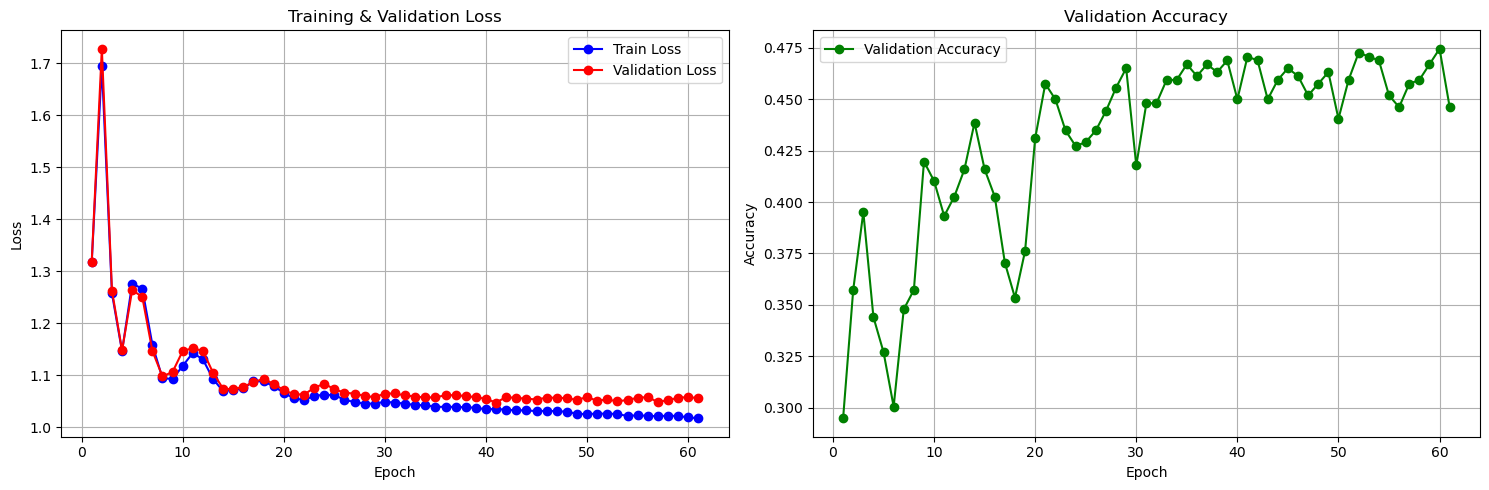

In [167]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize = (15, 5))

# Subplot 1: Losses
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label = "Train Loss", color = "blue", marker = "o")
plt.plot(epochs, val_losses, label = "Validation Loss", color = "red", marker = "o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.grid(True)
plt.legend()

# Subplot 2: Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, label = "Validation Accuracy", color = "green", marker = "o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Evaluate the Model on the Test Set

In [168]:
# Evaluate best model on test set
best_model.eval()
with torch.no_grad():
    out = best_model(data)  # [num_nodes, num_classes]
    pred = out.argmax(dim = 1)

    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred[data.test_mask].cpu().numpy()

    acc = (y_pred == y_true).mean()
    print(f"Best Config: {best_config}")
    print(f"Test Accuracy: {acc:.4f}")

Best Config: {'hidden_dim': [256], 'lr': 0.01, 'weight_decay': 0.001, 'optimizer': 'Adam', 'dropout_rate': 0.2}
Test Accuracy: 0.4576


### Confusion Matrix

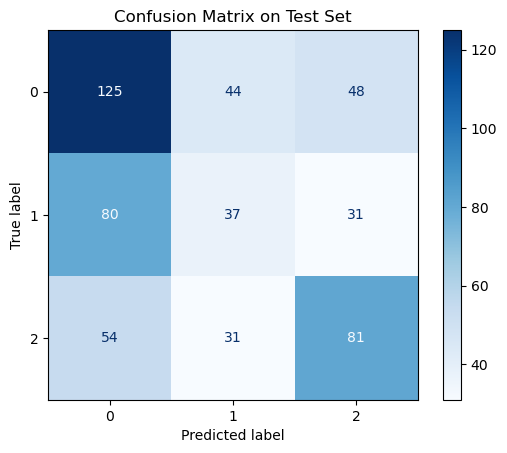

In [170]:
display_labels = np.unique(labels)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = display_labels)
disp.plot(cmap = plt.cm.Blues)
plt.title("Confusion Matrix on Test Set")
plt.show()


### Track Test Results

In [106]:
test_mask = data.test_mask.cpu().numpy()
test_indices = np.where(test_mask)[0]  # indices of test nodes

# Get movie names, true labels for test nodes
movie_ids_test = node_ids[valid_rows][test_indices]
true_labels_test = labels_filtered[test_indices]

true_ratings_test = ratings[valid_rows][test_indices]

df_test_results = pd.DataFrame({
    "movie_id": movie_ids_test,
    "rating": true_ratings_test,
    "true_label": true_labels_test,
    "pred_label": y_pred
})

df_test_results["correct"] = df_test_results["true_label"] == df_test_results["pred_label"]

accuracy = (df_test_results["true_label"] == df_test_results["pred_label"]).mean()
print(f"Test Accuracy: {accuracy:.3f}")

df_test_results.head(20)


Test Accuracy: 0.453


,movie_id,rating,true_label,pred_label,correct
0,Deadpool & Wolverine,7.125000,2,2,True
1,Rogue One: A Star Wars Story,7.550000,2,1,False
2,Jurassic World Dominion,4.750000,0,0,True
3,Star Wars: Episode I - The Phantom Menace,5.900000,1,2,False
4,Spider-Man: Homecoming,7.800000,2,2,True
5,Pirates of the Caribbean: Dead Men Tell No Tales,5.025000,0,1,False
6,X-Men: Days of Future Past,7.975000,2,2,True
7,Detective Chinatown 3,5.733333,0,1,False
8,Mission: Impossible - Rogue Nation,7.875000,2,2,True
9,Doctor Strange,7.750000,2,2,True


## Movie Revenue Classification

### Load Dataset and Preprocess

In [171]:
# Load GraphML with NetworkX
G = nx.read_graphml("../data/networks/movie_similarity_network.graphml")

# Extract node features and labels
node_ids = list(G.nodes)
num_nodes = len(node_ids)

# Pick node attributes as features
feature_names = ["budget", "oscar_noms", "rating"]
features = []
revenues = []

for n in node_ids:
    node_data = G.nodes[n]
    # Extract features and convert to float, handle missing data if needed
    f = []
    for attr in feature_names:
        val = node_data.get(attr)
        if val is None:
            val = 0.0  # or np.nan and handle later
        else:
            val = float(val)
        f.append(val)
    features.append(f)

    # Extract rating for label
    revenue_val = node_data.get("revenue")
    revenue_val = float(revenue_val) if revenue_val is not None else 0.0
    revenues.append(revenue_val)

numeric_features = np.array(features)
revenues = np.array(revenues)

### Encode Text Features

In [172]:
# Extract genre strings
genre_lists = []
for n in node_ids:
    raw = G.nodes[n].get("genre", "[]")
    try:
        genres = eval(raw)  # convert string to list
    except:
        genres = []
    genre_lists.append(genres)

# Convert to multi-hot encoding
mlb = MultiLabelBinarizer()
genre_features = mlb.fit_transform(genre_lists)

combined_features = np.hstack([numeric_features, genre_features])

### Bucketize Target Variables

In [173]:
# Bucketize revenue into classes
def bucketize_revenue_quantile(r, revenues, classes):
    quantiles = [np.quantile(revenues, i / classes) for i in range(1, classes)]
    
    for i, q in enumerate(quantiles):
        if r <= q:
            return i
    return classes - 1

classes = 5
labels = np.array([bucketize_revenue_quantile(r, revenues, classes) for r in revenues])

unique, counts = np.unique(labels, return_counts = True)

# Reverse normalization for human-readable interpretation
revenue_mean = 96_570_451.31396617
revenue_std = 184_222_950.90140792
quantiles = [np.quantile(revenues, i / classes) for i in range(1, classes)]
quantiles_original = [(q * revenue_std) + revenue_mean for q in quantiles]

# Print label bucket ranges
for label, count in zip(unique, counts):
    if label == 0:
        print(f"Label {label}: {count} movies - (revenue <= {quantiles_original[0]:,.2f})")
    elif label == classes - 1:
        print(f"Label {label}: {count} movies - (revenue > {quantiles_original[-1]:,.2f})")
    else:
        lower = quantiles_original[label - 1]
        upper = quantiles_original[label]
        print(f"Label {label}: {count} movies - ({lower:,.2f} < revenue <= {upper:,.2f})")

Label 0: 1388 movies - (revenue <= 3,787,518.60)
Label 1: 1388 movies - (3,787,518.60 < revenue <= 22,985,480.40)
Label 2: 1388 movies - (22,985,480.40 < revenue <= 57,324,747.00)
Label 3: 1388 movies - (57,324,747.00 < revenue <= 141,603,870.20)
Label 4: 1388 movies - (revenue > 141,603,870.20)


### Remove NaN Nodes and Edges

In [174]:
features = np.array(combined_features)  # shape (num_nodes, num_features)
labels = np.array(labels)      # your bucketized labels
node_ids = np.array(node_ids)  # original node_ids list (do NOT filter yet)

# Find valid nodes (no NaNs in features)
valid_rows = ~np.isnan(features).any(axis=1)

# Filter features and labels by valid_rows
features_filtered = features[valid_rows]
labels_filtered = labels[valid_rows]

# Build old_to_new mapping for all nodes (original order)
old_to_new = -np.ones(len(node_ids), dtype=int)
old_to_new[np.where(valid_rows)[0]] = np.arange(features_filtered.shape[0])

# Filter edges and remap node indices
edges = list(G.edges())
filtered_edges = []

# Create a mapping from node_id to original index to speed up lookups
node_id_to_idx = {nid: idx for idx, nid in enumerate(node_ids)}

for src, dst in edges:
    if src in node_id_to_idx and dst in node_id_to_idx:
        src_idx = node_id_to_idx[src]
        dst_idx = node_id_to_idx[dst]

        new_src = old_to_new[src_idx]
        new_dst = old_to_new[dst_idx]

        # Only keep edges where both nodes survived filtering
        if new_src != -1 and new_dst != -1:
            filtered_edges.append((new_src, new_dst))

# Build edge_index tensor (transpose to [2, num_edges])
edge_index = torch.tensor(filtered_edges, dtype = torch.long).t().contiguous()

num_nodes_filtered = features_filtered.shape[0]
print("Number of nodes before filtering:", len(node_ids))
print("Number of nodes before filtering:", num_nodes_filtered)

Number of nodes before filtering: 6940
Number of nodes before filtering: 6940


### Standardize Features and Convert to Torch Tensors

In [175]:
scaler = StandardScaler()
features_filtered = scaler.fit_transform(features_filtered)

# Convert to torch tensors
x = torch.tensor(features_filtered, dtype = torch.float)
y = torch.tensor(labels_filtered, dtype = torch.long)

### Split Dataset into Training, Validation, and Testing Sets

In [176]:
# Create train/test masks
num_nodes = num_nodes_filtered
num_train = int(0.8 * num_nodes)
num_val = int(0.1 * num_nodes)
num_test = num_nodes - num_train - num_val

perm = torch.randperm(num_nodes)
train_idx = perm[:num_train]
val_idx = perm[num_train : num_train + num_val]
test_idx = perm[num_train + num_val:]

train_mask = torch.zeros(num_nodes, dtype = torch.bool)
val_mask = torch.zeros(num_nodes, dtype = torch.bool)
test_mask = torch.zeros(num_nodes, dtype = torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

# Create data object
data = Data(x = x,
            edge_index = edge_index,
            y = y,
            train_mask = train_mask,
            val_mask = val_mask,
            test_mask = test_mask)

nan_mask = np.isnan(features_filtered)
print("NaNs per column:", np.sum(nan_mask, axis = 0))


NaNs per column: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### Tune Hyperparameters

In [177]:
param_grid = {
    "hidden_dim": [[256], [256, 256], [256, 256, 256]],
    "lr": [0.01, 0.001],
    "weight_decay": [5e-4, 1e-3],
    "optimizer": ["Adam", "SGD", "RMSprop"],
    "dropout_rate": [0.2, 0.3]
}

best_model, best_config, best_loss = hyperparameter_tuning(
    data = data,
    input_dim = x.shape[1],
    output_dim = len(np.unique(labels)),
    param_grid = param_grid,
    epochs = 200
)

# Print best model configuration
print(f"Best Config: {best_config}")
print(f"Best Validation Loss: {best_loss:.4f}")


Model 1/72: hidden_dim = [256] | lr = 0.01 | weight_decay = 0.0005 | optimizer = Adam | dropout_rate = 0.2
Early stopping triggered at epoch 129
Best Validation Loss: 1.1743

Model 2/72: hidden_dim = [256] | lr = 0.01 | weight_decay = 0.0005 | optimizer = Adam | dropout_rate = 0.3
Early stopping triggered at epoch 146
Best Validation Loss: 1.1502

Model 3/72: hidden_dim = [256] | lr = 0.01 | weight_decay = 0.0005 | optimizer = SGD | dropout_rate = 0.2
Best Validation Loss: 1.3797

Model 4/72: hidden_dim = [256] | lr = 0.01 | weight_decay = 0.0005 | optimizer = SGD | dropout_rate = 0.3
Best Validation Loss: 1.3659

Model 5/72: hidden_dim = [256] | lr = 0.01 | weight_decay = 0.0005 | optimizer = RMSprop | dropout_rate = 0.2
Early stopping triggered at epoch 104
Best Validation Loss: 1.2029

Model 6/72: hidden_dim = [256] | lr = 0.01 | weight_decay = 0.0005 | optimizer = RMSprop | dropout_rate = 0.3
Early stopping triggered at epoch 76
Best Validation Loss: 1.2244

Model 7/72: hidden_dim 

### Train the Best Model

In [178]:
# Retrain with best hyperparameters
best_model, best_val_loss, train_losses, val_accuracies, val_losses = train_model(
    data = data,
    input_dim = data.num_node_features,
    output_dim = len(np.unique(labels)),
    hidden_dim = best_config["hidden_dim"],
    lr = best_config["lr"],
    weight_decay = best_config["weight_decay"],
    optimizer_type = best_config["optimizer"],
    dropout_rate = best_config["dropout_rate"],
    epochs = 200
)

print(f"Best Model: {best_model}")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Early stopping triggered at epoch 185
Best Model: GCN_Rating_Classification(
  (convs): ModuleList(
    (0): GCNConv(22, 256)
    (1-2): 2 x GCNConv(256, 256)
  )
  (out): GCNConv(256, 5)
)
Best Validation Loss: 1.1402


### Visualize Training and Validation Results

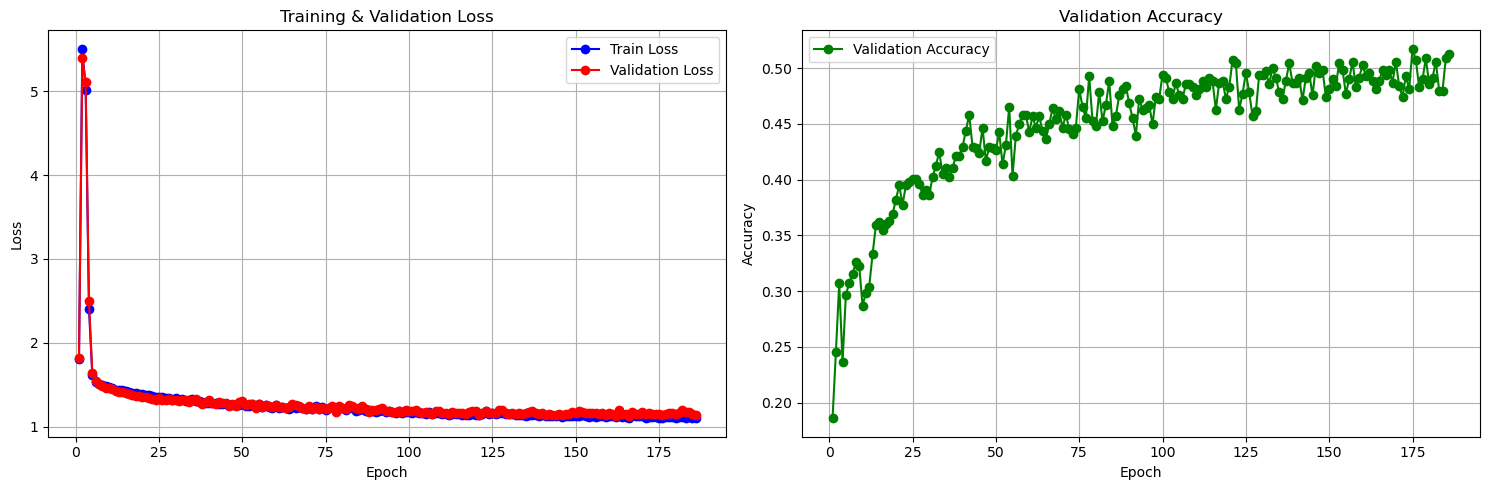

In [179]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize = (15, 5))

# Subplot 1: Losses
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label = "Train Loss", color = "blue", marker = "o")
plt.plot(epochs, val_losses, label = "Validation Loss", color = "red", marker = "o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.grid(True)
plt.legend()

# Subplot 2: Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, label = "Validation Accuracy", color = "green", marker = "o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Evaluate the Model on the Test Set

In [180]:
# Evaluate best model on test set
best_model.eval()
with torch.no_grad():
    out = best_model(data)  # [num_nodes, num_classes]
    pred = out.argmax(dim = 1)

    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred[data.test_mask].cpu().numpy()

    acc = (y_pred == y_true).mean()
    print(f"Best Config: {best_config}")
    print(f"Test Accuracy: {acc:.4f}")

Best Config: {'hidden_dim': [256, 256, 256], 'lr': 0.01, 'weight_decay': 0.0005, 'optimizer': 'Adam', 'dropout_rate': 0.2}
Test Accuracy: 0.4856


### Confusion Matrix

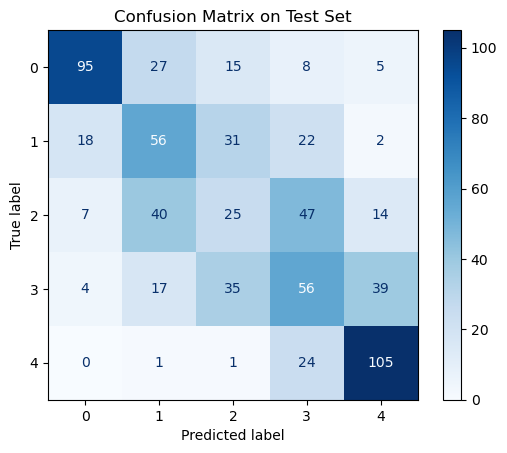

In [181]:
display_labels = np.unique(labels)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = display_labels)
disp.plot(cmap = plt.cm.Blues)
plt.title("Confusion Matrix on Test Set")
plt.show()


### Track Test Results

In [182]:
test_mask = data.test_mask.cpu().numpy()
test_indices = np.where(test_mask)[0]  # indices of test nodes

# Get movie names, true labels for test nodes
movie_ids_test = node_ids[valid_rows][test_indices]
true_labels_test = labels_filtered[test_indices]

true_revenue_test = revenues[valid_rows][test_indices]

revenue_mean = 96570451.31396617
revenue_std = 184222950.9014079

revenue_scalar_true = []
for i in true_revenue_test:
    value = (i * revenue_std) + revenue_mean
    revenue_scalar_true.append(value)

df_test_results = pd.DataFrame({
    "movie_id": movie_ids_test,
    "revenue_normalized": true_revenue_test,
    "revenue": revenue_scalar_true,
    "true_label": true_labels_test,
    "pred_label": y_pred
})

df_test_results["correct"] = df_test_results["true_label"] == df_test_results["pred_label"]

accuracy = (df_test_results["true_label"] == df_test_results["pred_label"]).mean()
print(f"Test Accuracy: {accuracy:.3f}")

df_test_results.head(60)


Test Accuracy: 0.486


,movie_id,revenue_normalized,revenue,true_label,pred_label,correct
0,Batman v Superman: Dawn of Justice,4.222017,8.743628e+08,4,4,True
1,Star Wars: Episode III - Revenge of the Sith,4.089770,8.500000e+08,4,4,True
2,Transformers: Revenge of the Fallen,4.015424,8.363037e+08,4,4,True
3,Wonder Woman,3.948478,8.239707e+08,4,4,True
4,Thor: Love and Thunder,3.606117,7.609000e+08,4,4,True
5,Pirates of the Caribbean: The Curse of the Bla...,3.031331,6.550112e+08,4,4,True
6,The Hunger Games: Mockingjay - Part 2,3.022739,6.534283e+08,4,4,True
7,Thor: The Dark World,2.975811,6.447831e+08,4,4,True
8,Fast Five,2.874395,6.261000e+08,4,4,True
9,The Lost World: Jurassic Park,2.833895,6.186390e+08,4,4,True
